In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_sauvola


In [2]:
DATASET_PATH = "/kaggle/input/lgg-mri-segmentation/kaggle_3m"


In [3]:
image_path = None
mask_path = None

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    for f in files:
        if f.endswith(".tif") and "mask" not in f:
            mask_name = f.replace(".tif", "_mask.tif")

            if mask_name in files:
                temp_mask = cv2.imread(
                    os.path.join(folder_path, mask_name),
                    cv2.IMREAD_GRAYSCALE
                )

                if np.sum(temp_mask) > 0:   # ensures tumor exists
                    image_path = os.path.join(folder_path, f)
                    mask_path  = os.path.join(folder_path, mask_name)
                    break

    if image_path is not None:
        break

print("Image path:", image_path)
print("Mask path :", mask_path)


Image path: /kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45.tif
Mask path : /kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45_mask.tif


In [4]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print("Image shape:", img.shape)
print("Mask shape :", mask.shape)


Image shape: (256, 256, 3)
Mask shape : (256, 256)


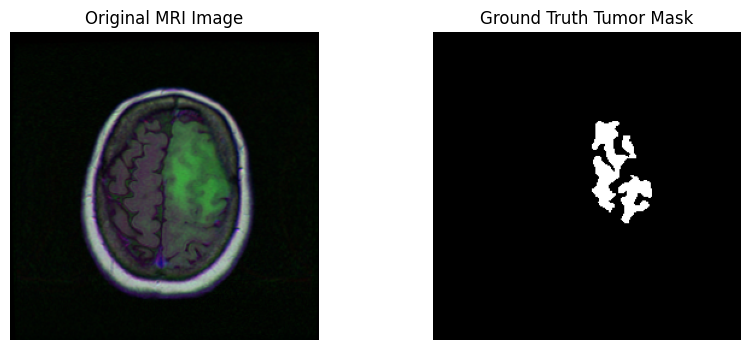

Mask unique values: [  0 255]


In [5]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Tumor Mask")
plt.axis("off")

plt.show()

print("Mask unique values:", np.unique(mask))


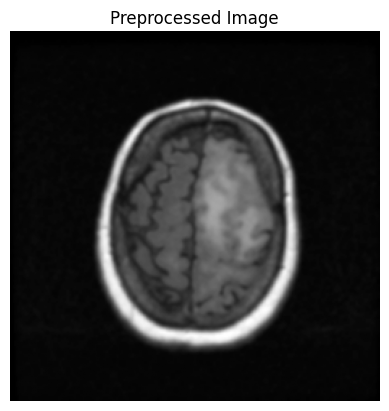

In [6]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()


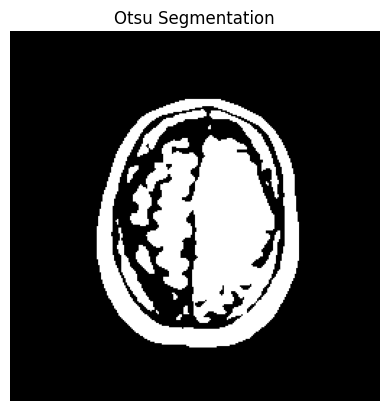

In [7]:
_, otsu = cv2.threshold(
    blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(otsu, cmap="gray")
plt.title("Otsu Segmentation")
plt.axis("off")
plt.show()


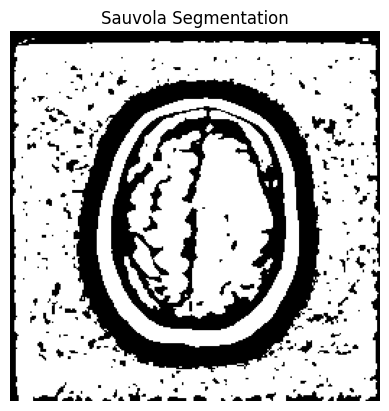

In [8]:
sauvola_thresh = threshold_sauvola(blur, window_size=25)
sauvola = blur > sauvola_thresh

plt.imshow(sauvola, cmap="gray")
plt.title("Sauvola Segmentation")
plt.axis("off")
plt.show()


In [9]:
# Apply morphological closing using a 5×5 kernel to remove noise and fill gaps in the segmented tumor regions

kernel = np.ones((5,5), np.uint8)

otsu_clean = cv2.morphologyEx(otsu, cv2.MORPH_CLOSE, kernel)
sauvola_clean = cv2.morphologyEx(
    sauvola.astype(np.uint8)*255,
    cv2.MORPH_CLOSE,
    kernel
)



In [10]:
mask_bin = (mask > 127).astype(np.uint8)

otsu_bin = (otsu_clean > 0).astype(np.uint8)
otsu_bin = 1 - otsu_bin   # inversion

sauvola_bin = (sauvola_clean > 0).astype(np.uint8)
sauvola_bin = 1 - sauvola_bin


In [11]:
def dice_score(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2 * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

def jaccard_index(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + 1e-7)


In [12]:
print("OTSU Dice      :", dice_score(mask_bin, otsu_bin))
print("OTSU Jaccard   :", jaccard_index(mask_bin, otsu_bin))

print("SAUVOLA Dice   :", dice_score(mask_bin, sauvola_bin))
print("SAUVOLA Jaccard:", jaccard_index(mask_bin, sauvola_bin))


OTSU Dice      : 3.882288997585445e-05
OTSU Jaccard   : 1.94118217994382e-05
SAUVOLA Dice   : 0.0006982021295124327
SAUVOLA Jaccard: 0.00034922297886997715


# Dice and Jaccard scores indicate very low overlap between the segmented output and the ground truth mask, with Otsu performing better than Sauvola .

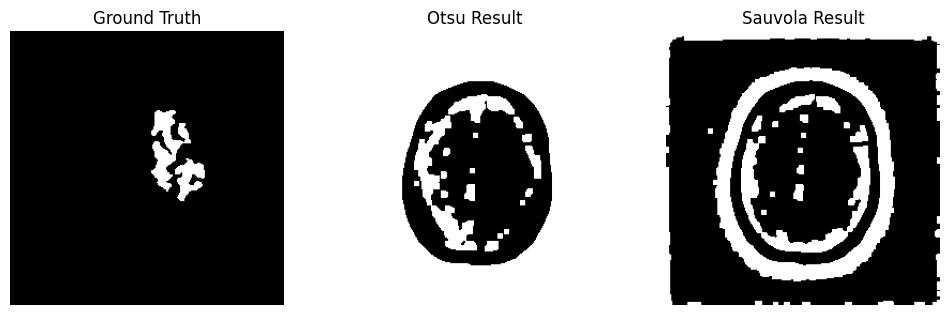

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(mask_bin, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(otsu_bin, cmap="gray")
plt.title("Otsu Result")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sauvola_bin, cmap="gray")
plt.title("Sauvola Result")
plt.axis("off")

plt.show()
